In [1]:
import os
import sys

sys.path.append('..')
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

import torch
import numpy as np
import random
import pylab as plt
import tqdm

from coronal_diffusion import dataset
from coronal_diffusion import visualization_tools as vt
from coronal_diffusion import sampler

import config

/home/dedasilv/micromamba/envs/coronal-diffusion/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/dedasilv/micromamba/envs/coronal-diffusion/lib/python3.11/site-packages/ai/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
def set_seeds(seed):
    torch.use_deterministic_algorithms(True)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

In [3]:
set_seeds(0)

In [4]:
os.chdir('..')
print('Current directory is:', os.getcwd())

Current directory is: /home/dedasilv/coronal-diffusion-modeling


In [5]:
sampling_data = sampler.load_sampling_data()

In [6]:
lats = np.arange(-90, 90, 2)
lons = np.arange(-180, 180, 2)

In [7]:
context = (50, 50, 15, 15, 1, -1),
img25, (G, H) = sampler.sample(sampling_data, weights_file='checkpoints/experiment59-cs-fix-and-context-scaling_16.pth', context=context, method='ddpm')

Denoising Step 1                 
Fitting spherical harmonics (45)


In [8]:
context = (10, 10, 5, 5, 1, -1),
img5, (G, H) = sampler.sample(sampling_data, weights_file='checkpoints/experiment59-cs-fix-and-context-scaling_16.pth', context=context, method='ddpm')

Denoising Step 1                 
Fitting spherical harmonics (45)


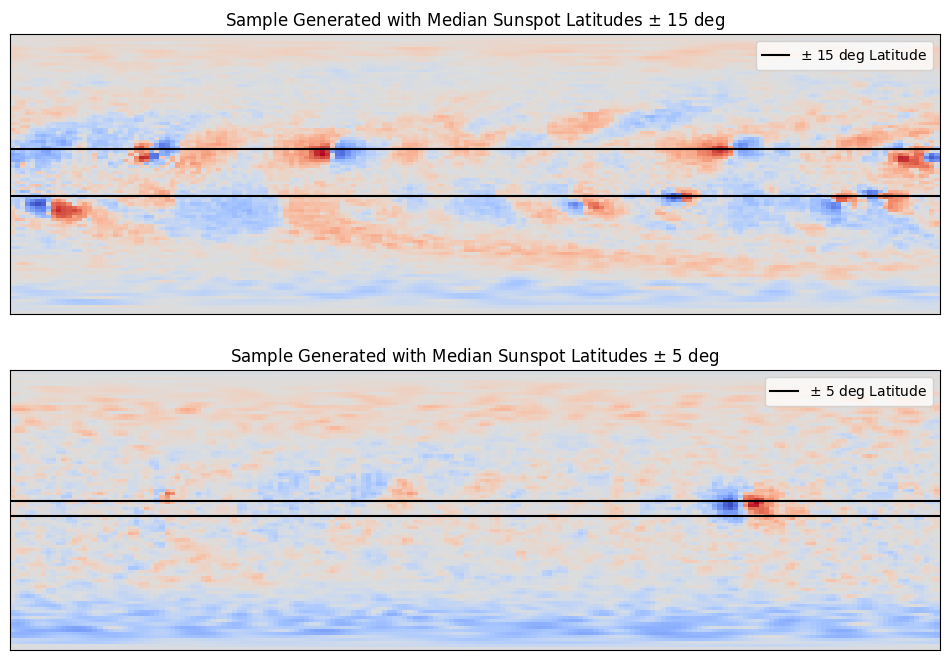

In [9]:

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

ax = axes[0]
ax.pcolor(lons, lats, img25[0], cmap='coolwarm_r')
ax.axhline(15, color='k', label='$\pm$ 15 deg Latitude')
ax.axhline(-15, color='k')
ax.set_title('Sample Generated with Median Sunspot Latitudes $\pm$ 15 deg')

ax = axes[1]
ax.pcolor(lons, lats, img5[0], cmap='coolwarm_r')
ax.axhline(5, color='k', label='$\pm$ 5 deg Latitude')
ax.axhline(-5, color='k')
ax.set_title('Sample Generated with Median Sunspot Latitudes $\pm$ 5 deg')

for ax in axes:
    ax.xaxis.set_ticks([])
    ax.yaxis.set_ticks([])
    ax.legend(loc='upper right')

fig.savefig('plots/paper/latitude_demo.png', dpi=300, bbox_inches='tight')